In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk


C:\Users\Lenovo-Pc\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Lenovo-Pc\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
data = pd.read_csv(r'D:\Project - Data Mining\Project\Data-Mining---Predictive-Maintenance-of-CNC-Machines\Local Repository\Data-Mining---Predictive-Maintenance-of-CNC-Machines\Pre-processing\Tool-Wear-forces\final_data_fy.csv')
data.head(5)

,Position,vc,cat,cont_1,cont_2,Fy
0,102.856364,107.474697,-64.875379,-15.439645,0.432755,44.46
1,102.856364,107.474697,-64.875379,-15.444645,0.091866,44.46
2,102.856364,107.474697,-64.875379,-15.438347,0.455781,44.46
3,102.856364,107.474697,-64.875379,-15.436054,0.532965,44.46
4,102.856364,107.474697,-64.875379,-15.443837,1.058478,44.46


In [3]:
X = data.iloc[:,0:6]
y = data.iloc[:,-1:7]

In [4]:
X

,Position,vc,cat,cont_1,cont_2,Fy
0,102.856364,107.474697,-64.875379,-15.439645,0.432755,44.46
1,102.856364,107.474697,-64.875379,-15.444645,0.091866,44.46
2,102.856364,107.474697,-64.875379,-15.438347,0.455781,44.46
3,102.856364,107.474697,-64.875379,-15.436054,0.532965,44.46
4,102.856364,107.474697,-64.875379,-15.443837,1.058478,44.46
...,...,...,...,...,...,...
607,91.290000,107.474697,221.210216,24.784547,2.885314,221.20
608,91.290000,107.474697,221.210216,24.790287,3.266256,221.20
609,91.290000,107.474697,221.210216,24.785142,3.665430,221.20
610,91.290000,107.474697,221.210216,24.785419,2.459472,221.20


In [5]:
y

,Fy
0,44.46
1,44.46
2,44.46
3,44.46
4,44.46
...,...
607,221.20
608,221.20
609,221.20
610,221.20


In [6]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size = 0.25, random_state = 42)
# Train => 60%, Test => 20%, Validation => 20%

In [7]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

# Create a pipeline: StandardScaler + SVR
model = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=100, epsilon=0.1))

# Fit on training data
model.fit(X_train, y_train)

# Predict on validation or test data
y_pred = model.predict(X_val)


C:\Users\Lenovo-Pc\anaconda3\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


In [8]:
from sklearn.metrics import mean_squared_error

y_pred = model.predict(X_val)
mse = mean_squared_error(y_val, y_pred)
mse

0.7340685789371205

In [9]:
from sklearn.metrics import mean_squared_error

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mse

0.24276520712791325

In [10]:
from sklearn.metrics import r2_score
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
r2

0.9999143949091625

In [11]:
y_train = y_train.values.ravel() 
y_test = y_test.values.ravel() 
y_val = y_val.values.ravel() 

y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)


y_train_pred = y_train_pred.ravel()
y_val_pred = y_val_pred.ravel()
y_test_pred = y_test_pred.ravel()


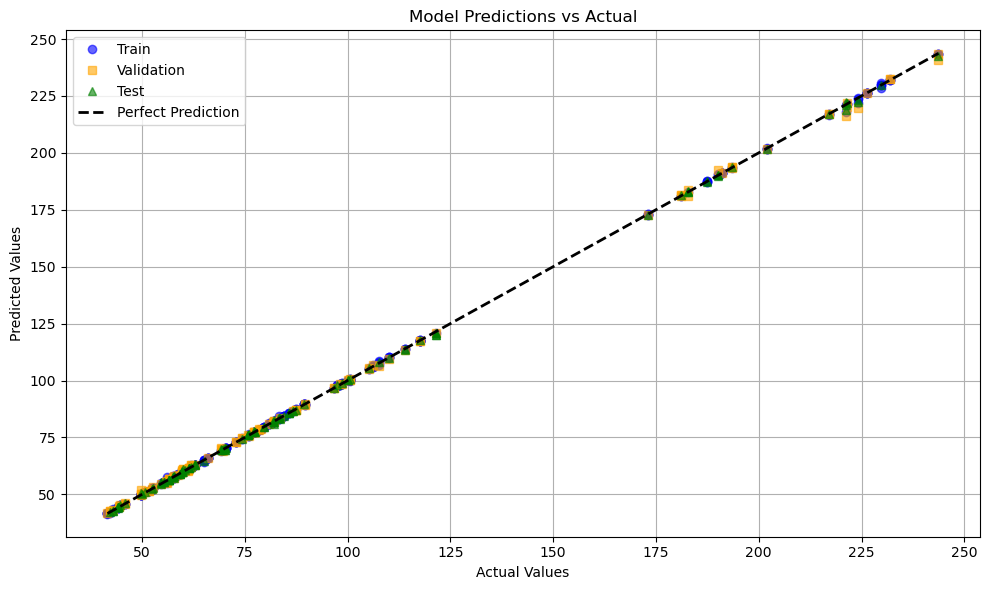

In [12]:
plt.figure(figsize=(10, 6))

plt.plot(y_train, y_train_pred, 'o', label='Train', color='blue', alpha=0.6)
plt.plot(y_val, y_val_pred, 's', label='Validation', color='orange', alpha=0.6)
plt.plot(y_test, y_test_pred, '^', label='Test', color='green', alpha=0.6)

# Reference perfect prediction line
min_val = min(y_train.min(), y_val.min(), y_test.min())
max_val = max(y_train.max(), y_val.max(), y_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Model Predictions vs Actual')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
